In [167]:
#22:42
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import RobustScaler, StandardScaler

In [168]:
df=pd.read_csv("docs/cybersecurity_intrusion_data.csv",na_values=['/','-',' ','','NA','null'])

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [170]:
df.isna().sum()

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

In [171]:
#1.	Učitati podatke i kreirati dataset. Izvršiti inicijalnu analizu (oblik, tipovi podataka, distribucija izlazne klase). Provjeriti da li je dataset balansiran i prokomentarisati eventualni disbalans u kontekstu problema detekcije napada.

In [172]:
# imamo session id koji je id tako da to dropujemo sigurno ne potrebno je za model i ne kaze nam nista ...
#imamo par kategorijskih kao protocol type , encrypction used i browser type ...

In [173]:
df.drop(columns='session_id',inplace=True)

In [174]:
df['protocol_type'].value_counts()# vidimo da je ova kategorijska nominalna ali iako je takva ja bi je napravio da bude onehot encodovana

protocol_type
TCP     6624
UDP     2406
ICMP     507
Name: count, dtype: int64

In [175]:
#df.drop(columns='protocol_type',inplace=True)
df=pd.get_dummies(data=df,columns=['protocol_type'],dtype=int)


In [176]:
#ovo je i izbacilo protocoly type ...
# sada trebamo da vidimo koliko je losa ova encrypction used
ukupno=df['encryption_used'].count()
na=df['encryption_used'].isna().sum()
procenatNa=na/ukupno
print(procenatNa.round(2))

0.26


In [177]:
#cetvrtina kolone je NA vrednosti u kolini encrypted used
#izbacujemo je zato
df.drop(columns='encryption_used',inplace=True)


In [178]:
df.isna().sum()

network_packet_size    0
login_attempts         0
session_duration       0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
protocol_type_ICMP     0
protocol_type_TCP      0
protocol_type_UDP      0
dtype: int64

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   login_attempts       9537 non-null   int64  
 2   session_duration     9537 non-null   float64
 3   ip_reputation_score  9537 non-null   float64
 4   failed_logins        9537 non-null   int64  
 5   browser_type         9537 non-null   object 
 6   unusual_time_access  9537 non-null   int64  
 7   attack_detected      9537 non-null   int64  
 8   protocol_type_ICMP   9537 non-null   int64  
 9   protocol_type_TCP    9537 non-null   int64  
 10  protocol_type_UDP    9537 non-null   int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 819.7+ KB


In [180]:
df['browser_type'].value_counts()#vidimo da imamo 5 vrsta brozrera gde chrome dominira i imamo uknown odlucejem da droppujem ovo jer nam ovo stvarno ne kaze koje browsere hakeri koriste ...
df.drop(columns='browser_type',inplace=True)


In [181]:
df.describe()#vidimo da se max vr dosta razlikuju treba nam skaliranje ...

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,protocol_type_ICMP,protocol_type_TCP,protocol_type_UDP
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101,0.053161,0.694558,0.252281
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220,0.224367,0.460619,0.434344
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [182]:
from scipy.stats import kstest
import numpy as np

numericke = ['network_packet_size', 'login_attempts',
             'session_duration', 'ip_reputation_score', 'failed_logins']

for col in numericke:
    # normalizujemo jer KS testira vs standardne normalne raspodele
    data = (df[col] - df[col].mean()) / df[col].std()
    stat, p = kstest(data, 'norm')
    if p < 0.05:
        print(f"kolona: {col} | NIJE normalna | p = {round(p, 4)}")
    else:
        print(f"kolona: {col} | JESTE normalna | p = {round(p, 4)}")

kolona: network_packet_size | NIJE normalna | p = 0.0496
kolona: login_attempts | NIJE normalna | p = 0.0
kolona: session_duration | NIJE normalna | p = 0.0
kolona: ip_reputation_score | NIJE normalna | p = 0.0
kolona: failed_logins | NIJE normalna | p = 0.0


In [183]:
df['attack_detected']

0       1
1       0
2       1
3       1
4       0
       ..
9532    1
9533    0
9534    0
9535    0
9536    1
Name: attack_detected, Length: 9537, dtype: int64

In [184]:
from sklearn.model_selection import train_test_split
X=df.drop(columns='attack_detected')
y=df['attack_detected']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

In [185]:
X.columns

Index(['network_packet_size', 'login_attempts', 'session_duration',
       'ip_reputation_score', 'failed_logins', 'unusual_time_access',
       'protocol_type_ICMP', 'protocol_type_TCP', 'protocol_type_UDP'],
      dtype='object')

In [186]:
#kako nijedna kolona nema normalnu raspodelu
#radimo standard scaler jer profesor uvek radi na neuronskim standard
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(X.drop(columns=['protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP'])),
    columns=['network_packet_size', 'login_attempts', 'session_duration',
       'ip_reputation_score', 'failed_logins', 'unusual_time_access'])




In [187]:
df_scaled[['protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP']]=X[['protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP']]

In [188]:
df_scaled

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,protocol_type_ICMP,protocol_type_TCP,protocol_type_UDP
0,0.496899,-0.016346,-0.381125,1.554930,-0.500779,-0.419989,0,1,0
1,-0.143322,-0.525794,0.972960,-0.168029,-1.467959,-0.419989,0,1,0
2,0.648132,-0.525794,-0.912503,2.301950,0.466400,-0.419989,0,1,0
3,1.530327,-0.016346,-0.243473,-1.174443,-1.467959,-0.419989,0,0,1
4,-0.239103,0.493102,-0.330830,-1.560484,-0.500779,-0.419989,0,1,0
...,...,...,...,...,...,...,...,...,...
9532,-1.544751,-0.525794,-0.720511,1.052117,1.433580,-0.419989,1,0,0
9533,-0.607104,-0.525794,-0.775438,0.435452,-1.467959,-0.419989,0,1,0
9534,0.824571,0.493102,-0.963200,0.157266,-0.500779,-0.419989,0,1,0
9535,-0.476035,-0.016346,-0.897729,1.163198,-0.500779,2.381015,0,1,0


In [189]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(hidden_layer_sizes=(64,16),random_state=42, max_iter=10000,verbose=1,solver="adam").fit(X_train, y_train)
#arhitektura neurosnke mreze :
    #imamo  9 ulaza to su kolene df_scaleda,
    #onda imamo 2 hidden layera , prvi sa 64 neurona, i drugi sa 16 ,
    #na kraju imamo jedan izlaz
    #sta se desava dok se trenira model neurosnke mreze;
    #desavaju se jedan proces u 4 korak
    #1.ForwardPropaganation .... ulazni podaci iz dfa idu kroz sve slojeve na svakom sloju se primenjiju tezina i bias , izlaz se prosledjuje sledecem sloju i na kraju imamo rezultat koji je predikcija modela za svaki uzorak .
    #2 korak je racunanje greske loss , koji je prikaza ispod u prvoj iteraciji je bio 12.2 uporedjuju se stvarne vrednosti sa y_train vrednostima greska se racuna loss funkcijom cilj je sto manja greska
    #3 korak je backward propaganation greska ide unazad kroz mrezu i vraca se racuna se gradijent . kako svaka tezina utice na mrezu i odredjuje se smer i velicina sledeceih tezina ...
    #korak 4 optimizacija i azuriranje parametra tezine i bias se azuriraju cilj je smanjiti sto vise gresku ...
    #ovaj jedn prolaz kroz 4 koraka je prva iteracija idemo sve do max iter ili do prestanka zbog toga sto je zadovoljena tolerancije

Iteration 1, loss = 12.25347314
Iteration 2, loss = 3.11903954
Iteration 3, loss = 0.93217990
Iteration 4, loss = 0.78087701
Iteration 5, loss = 0.72830585
Iteration 6, loss = 0.70017337
Iteration 7, loss = 0.68790265
Iteration 8, loss = 0.75907682
Iteration 9, loss = 0.67864402
Iteration 10, loss = 0.69284835
Iteration 11, loss = 0.75122409
Iteration 12, loss = 0.66195597
Iteration 13, loss = 0.67308306
Iteration 14, loss = 0.70762289
Iteration 15, loss = 0.74805238
Iteration 16, loss = 0.63332166
Iteration 17, loss = 0.67999850
Iteration 18, loss = 0.67630536
Iteration 19, loss = 0.66235674
Iteration 20, loss = 0.66846689
Iteration 21, loss = 0.74103330
Iteration 22, loss = 0.76512737
Iteration 23, loss = 0.70454453
Iteration 24, loss = 0.64869156
Iteration 25, loss = 0.75218868
Iteration 26, loss = 0.61624684
Iteration 27, loss = 0.64214487
Iteration 28, loss = 0.67205397
Iteration 29, loss = 0.65699946
Iteration 30, loss = 0.88206243
Iteration 31, loss = 0.63104168
Iteration 32, lo

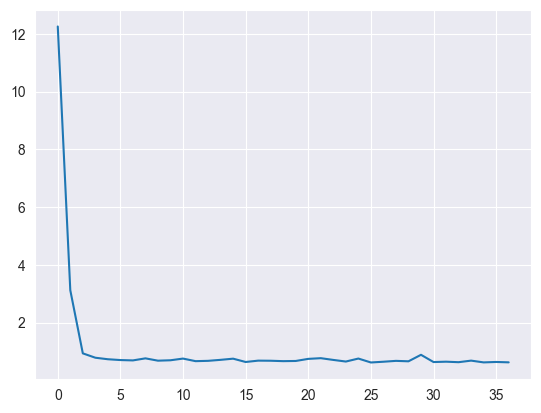

In [190]:
plt.figure()
plt.plot(clf.loss_curve_)

In [191]:
y_pred=clf.predict(X_test)

In [214]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
konfuzijaaaa=confusion_matrix(y_test,y_pred)
konfuzijaaaa


array([[964,  91],
       [518, 335]])

In [193]:
cl=classification_report(y_test,y_pred)
print(cl)
#imamo 4 metrike za procenu klasifikatora to su
#Precision je metrika koja vraca broj stvarno tacnih predvidjanja od svih tacnih predvidjanja formula tp/tp+fp
#Reccal je metrika meri sposobnost klasifikatora da nadje sve pozitivne obzervacije , najbolja vr je 1 najgora 0 , formula tp/tp+fn
#f1 score je metrika je harmonisjka sredina precisina i reccala jer su oni obrnuto procorionalni, formula je f1=2*TP/2*TP +FP + FN
#formula accuray tp+tn/tp + tn +fn +fp je metrika koja meri procenat tacnih predikcija u odnosu na sva predvidjanja.
#u donosu na moj model
# precision za pozitivnu klasu da se desi cyberattack je 0.79 , model je predvideo skoro 80% svih cyberattackova koji su se desili
# recall za pozitivnu klasu da se desi cybearattack je skoro 0.40 , od svih sesija predvidjanih da ce biti cyberattack 40% je stvarno cyberattack

#f1 score je 52% , kako je ova metrika balansira precision i reccal a precision je visok a reccal je rel nizak f score ih balansira i negde je prosecan ..

#accuracy za 68% sesija je tacno predvidjeno da li ce se desiti cyberattack ili ne ...

              precision    recall  f1-score   support

           0       0.65      0.91      0.76      1055
           1       0.79      0.39      0.52       853

    accuracy                           0.68      1908
   macro avg       0.72      0.65      0.64      1908
weighted avg       0.71      0.68      0.65      1908



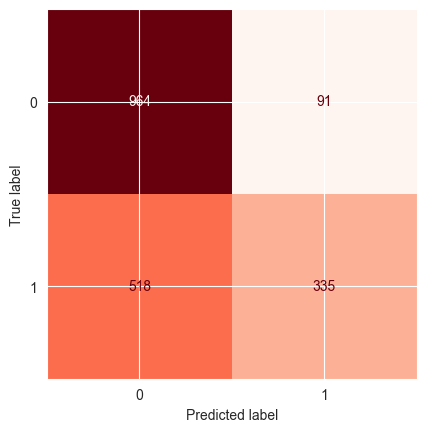

In [213]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_,)
disp.plot(cmap="Reds",colorbar=False)
plt.show()

In [ ]:
#Matrica konfuzije : TN-model predvidja 964 obzervacija u kojima smo tacno predvideli da se napad nece desiti i nije se zapravo desio
#TP-model preddja 335 sesija desio cyberattack i on se tada stvarno desio
#FP- model predvidja 91 sesiju kao cyberattack ali se ona tada nije desila u stvarnosti
#FN- model predvidja 518 sesija kao da se nije desio cyberattack ali su oni u stvarnosti cybberatack
#na glavnoj dijagonali se nalaze tacna predvidjanja , a na sporednoj se nalaze netacna predvidjanja ...
#FN greska koja se javlja je najopasnija...
